# European Consumer Risk Simulation & Macroeconomic Stress Testing

## Project Overview

This project analyzes macroeconomic consumer risk across European countries using three key indicators:

- Inflation rate
- Unemployment rate
- Household consumption index

The goal is to build an early-warning framework that identifies countries with elevated consumer economic stress and simulates future consumption uncertainty using Monte Carlo simulation.

## Business Problem

Banks, fintech companies, policy analysts, and investment teams need to understand where consumer financial stress is increasing across Europe.

This analysis helps answer:

- Which European countries show the highest macroeconomic consumer risk?
- What indicators are driving risk?
- How has risk changed over time?
- Which countries show the highest future consumption uncertainty?
- What is the probability of severe consumption downside scenarios?

## Project Outputs

This project includes:

- Cleaned and merged macroeconomic datasets
- Economic risk scoring model
- Country-level risk rankings
- Monte Carlo simulation forecasts
- Python visualizations

In [7]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# 1. Load Processed Data

The analysis uses processed CSV files generated from the Python data pipeline.

The main datasets are:

- `economic_risk_dataset.csv`: merged macroeconomic indicators
- `economic_risk_scored.csv`: final dataset with standardized variables and risk scores
- `monte_carlo_summary.csv`: summarized Monte Carlo forecast outputs

In [15]:
import os
import pandas as pd

project_path = r"C:\Users\admin\Desktop\european-consumer-risk-simulation"

os.chdir(project_path)

print("Current folder:")
print(os.getcwd())

print("\nFiles in data/processed:")
print(os.listdir("data/processed"))

Current folder:
C:\Users\admin\Desktop\european-consumer-risk-simulation

Files in data/processed:
['consumption_clean.csv', 'economic_risk_dataset.csv', 'economic_risk_scored.csv', 'inflation_clean.csv', 'monte_carlo_simulations.csv', 'monte_carlo_summary.csv', 'unemployment_clean.csv']


In [17]:
risk_data = pd.read_csv(
    "data/processed/economic_risk_dataset.csv"
)

risk_scored = pd.read_csv(
    "data/processed/economic_risk_scored.csv"
)

monte_carlo = pd.read_csv(
    "data/processed/monte_carlo_summary.csv"
)

print("Base dataset shape:", risk_data.shape)
print("Scored dataset shape:", risk_scored.shape)
print("Monte Carlo summary shape:", monte_carlo.shape)

Base dataset shape: (432, 5)
Scored dataset shape: (432, 10)
Monte Carlo summary shape: (135, 9)


# 2. Dataset Overview

The project combines three macroeconomic indicators across European countries:

- Inflation rate
- Unemployment rate
- Household consumption index

These indicators are merged into a unified analytical dataset and transformed into a standardized economic risk scoring model.

The final datasets include:
- cleaned macroeconomic indicators,
- standardized z-score features,
- calculated economic risk scores,
- Monte Carlo forecast outputs.

In [19]:
risk_scored.head()

,country,year,inflation_rate,unemployment_rate,consumption_index,inflation_z,unemployment_z,consumption_z,risk_score,risk_level
0,Austria,2010,1.691667,5.191667,92.066312,-0.301298,-0.678453,-0.494949,-0.330626,Medium Risk
1,Austria,2011,3.541667,4.875000,95.081250,0.300269,-0.750141,-0.278063,-0.229377,Medium Risk
2,Austria,2012,2.558333,5.241667,95.641937,-0.019483,-0.667134,-0.237729,-0.291866,Medium Risk
3,Austria,2013,2.116667,5.708333,95.337250,-0.163100,-0.561489,-0.259648,-0.277745,Medium Risk
4,Austria,2014,1.458333,6.033333,96.283125,-0.377171,-0.487914,-0.191604,-0.318788,Medium Risk


# 3. Data Quality & Validation

Before performing risk analysis, the datasets were validated to ensure:

- no missing values,
- consistent country coverage,
- yearly aggregation consistency,
- valid numerical ranges,
- and standardized economic indicators.

This step is important because inaccurate macroeconomic data would directly distort the risk scoring model and Monte Carlo simulation outputs.

In [21]:
# CHECK MISSING VALUES

print("Missing Values:\n")

display(
    risk_scored.isnull().sum()
)

Missing Values:



country              0
year                 0
inflation_rate       0
unemployment_rate    0
consumption_index    0
inflation_z          0
unemployment_z       0
consumption_z        0
risk_score           0
risk_level           0
dtype: int64

In [23]:
# COUNTRY COVERAGE

print("Number of countries:")
print(risk_scored["country"].nunique())

print("\nCountries included:\n")

print(
    sorted(
        risk_scored["country"].unique()
    )
)

Number of countries:
27

Countries included:

['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']


In [25]:
# YEAR RANGE

print("Minimum year:")
print(risk_scored["year"].min())

print("\nMaximum year:")
print(risk_scored["year"].max())

Minimum year:
2010

Maximum year:
2025


# 4. Exploratory Data Analysis

This section explores how inflation, unemployment, consumption, and economic risk evolved over time across European countries.

In [27]:
# Average yearly macroeconomic indicators

yearly_avg = (
    risk_scored
    .groupby("year", as_index=False)
    .agg(
        avg_inflation=("inflation_rate", "mean"),
        avg_unemployment=("unemployment_rate", "mean"),
        avg_consumption=("consumption_index", "mean"),
        avg_risk_score=("risk_score", "mean")
    )
)

yearly_avg.head()

,year,avg_inflation,avg_unemployment,avg_consumption,avg_risk_score
0,2010,1.978086,10.458642,84.935977,0.396077
1,2011,3.188580,10.393827,86.296683,0.487249
2,2012,2.879012,11.144753,85.772192,0.549594
3,2013,1.310494,11.507716,85.909736,0.435688
4,2014,0.282407,10.845988,87.894625,0.231938


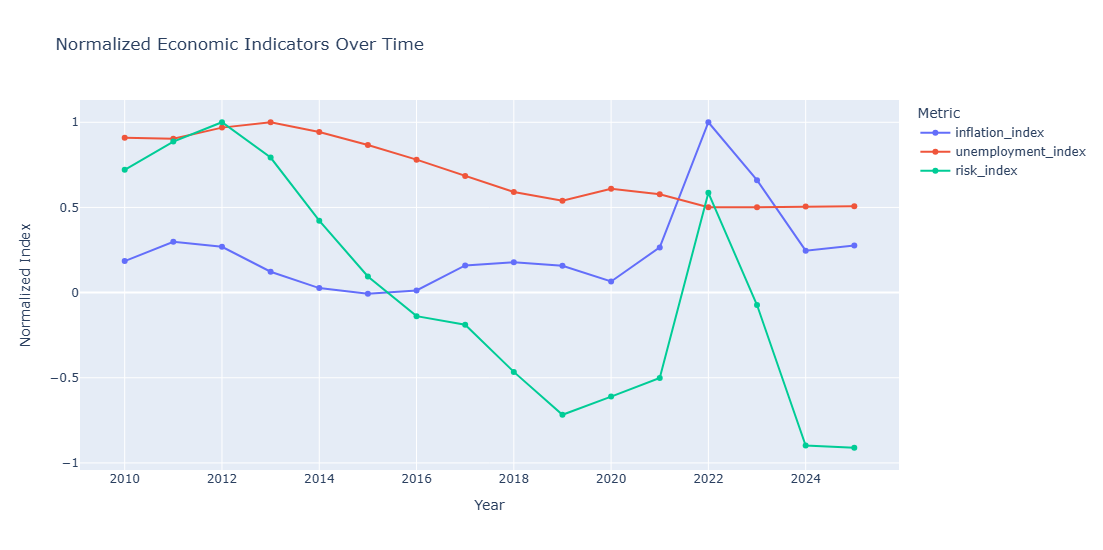

In [32]:
# NORMALIZED TREND VISUALIZATION

normalized = yearly_avg.copy()

normalized["inflation_index"] = (
    normalized["avg_inflation"]
    / normalized["avg_inflation"].max()
)

normalized["unemployment_index"] = (
    normalized["avg_unemployment"]
    / normalized["avg_unemployment"].max()
)

normalized["risk_index"] = (
    normalized["avg_risk_score"]
    / normalized["avg_risk_score"].max()
)

fig = px.line(
    normalized,
    x="year",
    y=[
        "inflation_index",
        "unemployment_index",
        "risk_index"
    ],
    markers=True,
    title="Normalized Economic Indicators Over Time"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Normalized Index",
    legend_title="Metric",
    height=550
)

fig.show()

# 5. Country-Level Risk Analysis

The next step is to compare long-run economic risk across European countries. To reduce short-term volatility, the analysis uses multi-year average risk scores rather than only the latest year. This helps identify structurally higher-risk economies across the entire analysis period.

In [34]:
# MULTI-YEAR COUNTRY RISK AVERAGES

country_risk = (
    risk_scored
    .groupby("country", as_index=False)
    .agg(
        avg_risk_score=("risk_score", "mean"),
        avg_inflation=("inflation_rate", "mean"),
        avg_unemployment=("unemployment_rate", "mean"),
        avg_consumption=("consumption_index", "mean")
    )
)

country_risk = (
    country_risk
    .sort_values(
        "avg_risk_score",
        ascending=False
    )
)

country_risk.head(10)

,country,avg_risk_score,avg_inflation,avg_unemployment,avg_consumption
11,Greece,0.908352,1.667708,18.343229,109.256816
25,Spain,0.903567,2.029167,17.661458,106.676426
16,Lithuania,0.270804,3.512500,9.266667,94.669246
15,Latvia,0.261813,3.103646,9.882812,97.369453
23,Slovakia,0.196089,3.201563,9.176042,97.041047
3,Croatia,0.180400,2.638021,10.535417,105.005270
7,Estonia,0.173463,4.199479,7.730729,94.009082
13,Ireland,0.146976,1.416667,8.552604,83.447602
22,Romania,0.088796,4.273438,6.914062,93.970305
21,Portugal,0.072795,1.951563,10.072917,104.191277


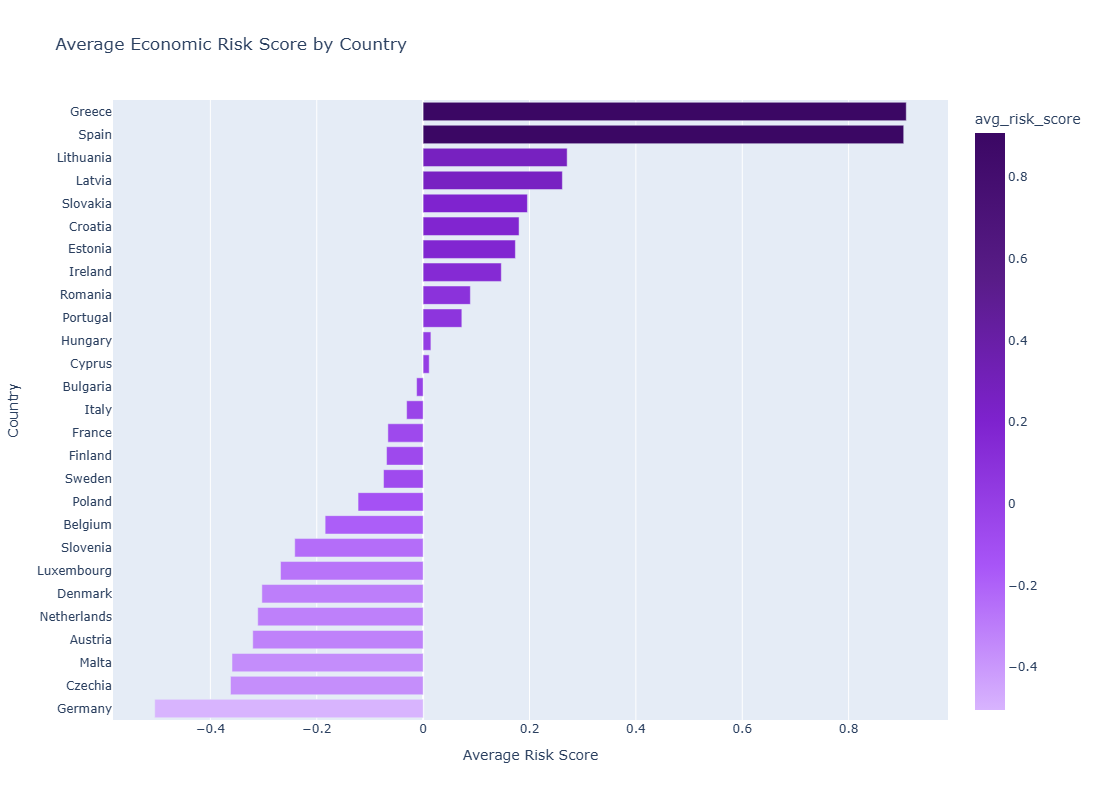

In [36]:
fig = px.bar(
    country_risk.sort_values(
        "avg_risk_score",
        ascending=True
    ),
    x="avg_risk_score",
    y="country",
    orientation="h",
    color="avg_risk_score",
    color_continuous_scale=[
        "#D8B4FE",
        "#A855F7",
        "#7E22CE",
        "#581C87",
        "#3B0764"
    ],
    title="Average Economic Risk Score by Country"
)

fig.update_layout(
    height=800,
    xaxis_title="Average Risk Score",
    yaxis_title="Country"
)

fig.show()

# 6. European Economic Risk Heatmap

The following map visualizes average multi-year macroeconomic consumer risk across European countries. Darker regions indicate structurally higher long-run economic risk.

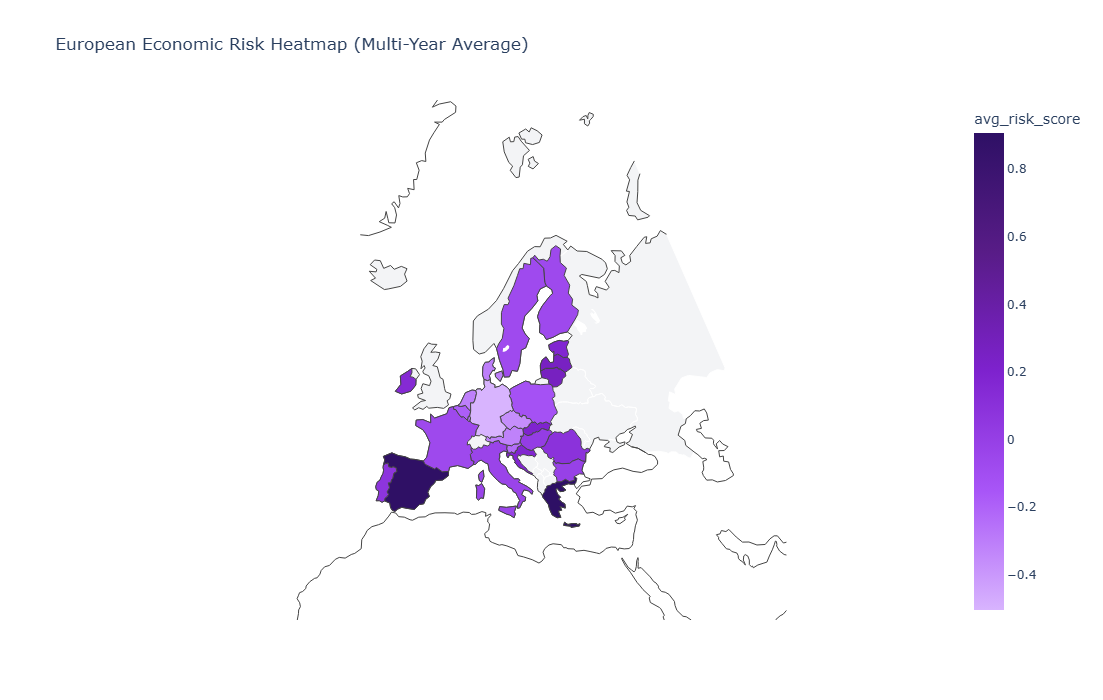

In [38]:
# EUROPEAN RISK HEATMAP

fig = px.choropleth(
    country_risk,
    locations="country",
    locationmode="country names",
    color="avg_risk_score",
    hover_name="country",
    hover_data={
        "avg_risk_score": ":.3f",
        "avg_inflation": ":.2f",
        "avg_unemployment": ":.2f",
        "avg_consumption": ":.2f",
        "country": False
    },
    color_continuous_scale=[
        "#D8B4FE",
        "#A855F7",
        "#7E22CE",
        "#581C87",
        "#2E1065"
    ],
    title="European Economic Risk Heatmap (Multi-Year Average)"
)

fig.update_geos(
    scope="europe",
    showcountries=True,
    showcoastlines=True,
    showland=True,
    landcolor="#F3F4F6",
    countrycolor="white"
)

fig.update_layout(
    height=700
)

fig.show()

# 7. Risk Scoring Methodology

The economic risk score is based on standardized macroeconomic indicators.

The model assumes that:

- higher inflation increases consumer stress,
- higher unemployment increases consumer stress,
- higher household consumption reduces economic risk.

The final weighted risk score is:

Risk Score = 0.30 × Inflation Z-Score + 0.50 × Unemployment Z-Score − 0.20 × Consumption Z-Score

Unemployment receives the highest weight because labor-market weakness is usually one of the strongest signals of consumer financial stress.

In [40]:
# RISK SCORE COMPONENTS

risk_scored["inflation_component"] = 0.30 * risk_scored["inflation_z"]
risk_scored["unemployment_component"] = 0.50 * risk_scored["unemployment_z"]
risk_scored["consumption_component"] = -0.20 * risk_scored["consumption_z"]

component_summary = risk_scored[
    [
        "inflation_component",
        "unemployment_component",
        "consumption_component",
        "risk_score"
    ]
].describe()

component_summary

,inflation_component,unemployment_component,consumption_component,risk_score
count,4.320000e+02,4.320000e+02,4.320000e+02,4.320000e+02
mean,8.223874e-18,8.223874e-18,-3.803542e-17,-2.467162e-17
std,3.003478e-01,5.005797e-01,2.002319e-01,5.556704e-01
min,-4.114963e-01,-6.976653e-01,-5.770884e-01,-1.180966e+00
25%,-1.814374e-01,-3.184747e-01,-1.348152e-01,-3.734823e-01
50%,-5.583993e-02,-1.359539e-01,-1.515612e-02,-1.071883e-01
75%,6.569293e-02,1.658893e-01,1.207718e-01,2.774467e-01
max,1.634646e+00,2.218895e+00,7.057252e-01,1.972267e+00


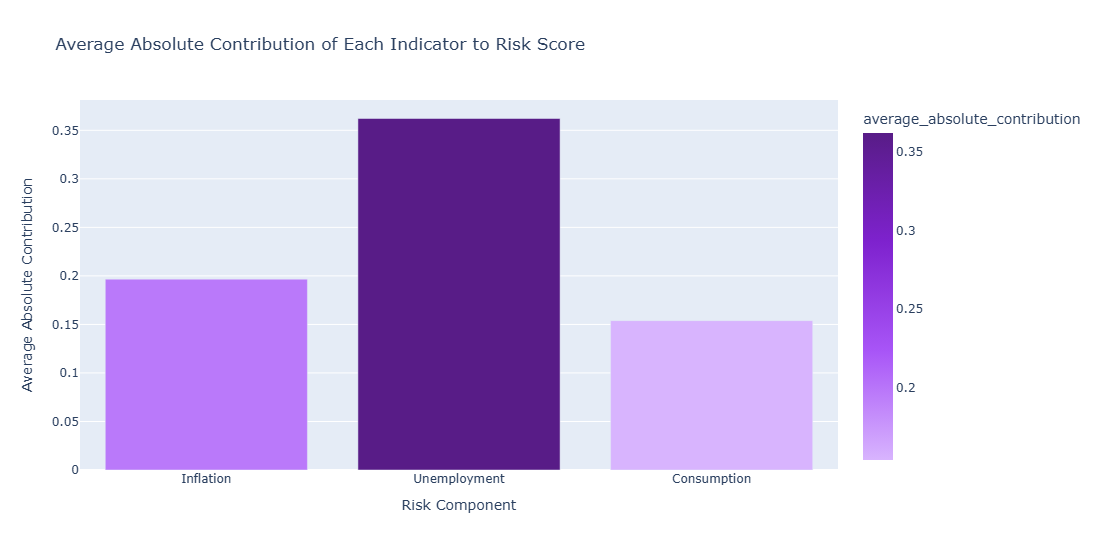

In [44]:
# ABSOLUTE RISK CONTRIBUTION

component_strength = pd.DataFrame({
    "component": [
        "Inflation",
        "Unemployment",
        "Consumption"
    ],
    "average_absolute_contribution": [
        risk_scored["inflation_component"].abs().mean(),
        risk_scored["unemployment_component"].abs().mean(),
        risk_scored["consumption_component"].abs().mean()
    ]
})

fig = px.bar(
    component_strength,
    x="component",
    y="average_absolute_contribution",
    color="average_absolute_contribution",
    color_continuous_scale=[
        "#D8B4FE",
        "#A855F7",
        "#7E22CE",
        "#581C87"
    ],
    title="Average Absolute Contribution of Each Indicator to Risk Score"
)

fig.update_layout(
    height=550,
    xaxis_title="Risk Component",
    yaxis_title="Average Absolute Contribution"
)

fig.show()

# 8. Monte Carlo Simulation & Forecasting

To model future uncertainty, the project applies Monte Carlo simulation to household consumption forecasts.

The simulation uses:

- historical average consumption growth,
- historical volatility,
- and randomized economic shocks.

For each country:
- thousands of future consumption paths are simulated,
- forecast confidence intervals are generated,
- and downside economic scenarios are estimated.

This allows the model to evaluate:
- future uncertainty,
- forecast stability,
- and potential consumer stress scenarios.

In [46]:
# MONTE CARLO DATA PREVIEW

monte_carlo.head()

,country,forecast_year,expected_value,downside_5th_percentile,upside_95th_percentile,median_forecast,forecast_std,forecast_range,crisis_probability
0,Austria,2026,111.221739,105.670357,116.767390,111.264418,3.365501,11.097033,0.0000
1,Austria,2027,112.637252,104.800221,120.625262,112.594495,4.799534,15.825042,0.0001
2,Austria,2028,113.984678,104.400474,123.759787,113.907102,5.934178,19.359313,0.0003
3,Austria,2029,115.369154,104.290079,126.960801,115.236732,6.940571,22.670722,0.0006
4,Austria,2030,116.783078,104.253732,130.018300,116.570967,7.829009,25.764568,0.0016


In [48]:
# HIGHEST FORECAST UNCERTAINTY

monte_carlo.sort_values(
    "forecast_range",
    ascending=False
).head(10)

,country,forecast_year,expected_value,downside_5th_percentile,upside_95th_percentile,median_forecast,forecast_std,forecast_range,crisis_probability
69,Ireland,2030,172.983678,133.828527,216.699495,171.586721,25.248973,82.870968,0.0000
68,Ireland,2029,162.211238,129.664138,198.626286,161.027309,21.148332,68.962147,0.0002
24,Cyprus,2030,160.134224,131.444940,191.477107,159.363596,18.359357,60.032167,0.0001
67,Ireland,2028,152.241604,125.669813,182.103140,151.526693,17.207729,56.433327,0.0000
94,Malta,2030,185.666201,160.009221,213.677028,185.028934,16.183448,53.667807,0.0000
23,Cyprus,2029,155.124117,130.196122,182.232944,154.426816,15.935049,52.036822,0.0000
59,Greece,2030,122.182385,99.595406,146.391108,121.676173,14.169594,46.795702,0.0211
19,Croatia,2030,153.049486,130.719537,177.142987,152.506780,14.187558,46.423450,0.0000
93,Malta,2029,175.188854,153.453039,198.447612,174.737912,13.570256,44.994572,0.0000
22,Cyprus,2028,150.506364,129.248722,173.380349,149.944659,13.434939,44.131627,0.0000


# 9 Monte Carlo Forecast Confidence Bands

The simulation generates confidence intervals for future household consumption forecasts. The shaded region represents the simulated 5th–95th percentile range, while the center line represents the expected forecast value.

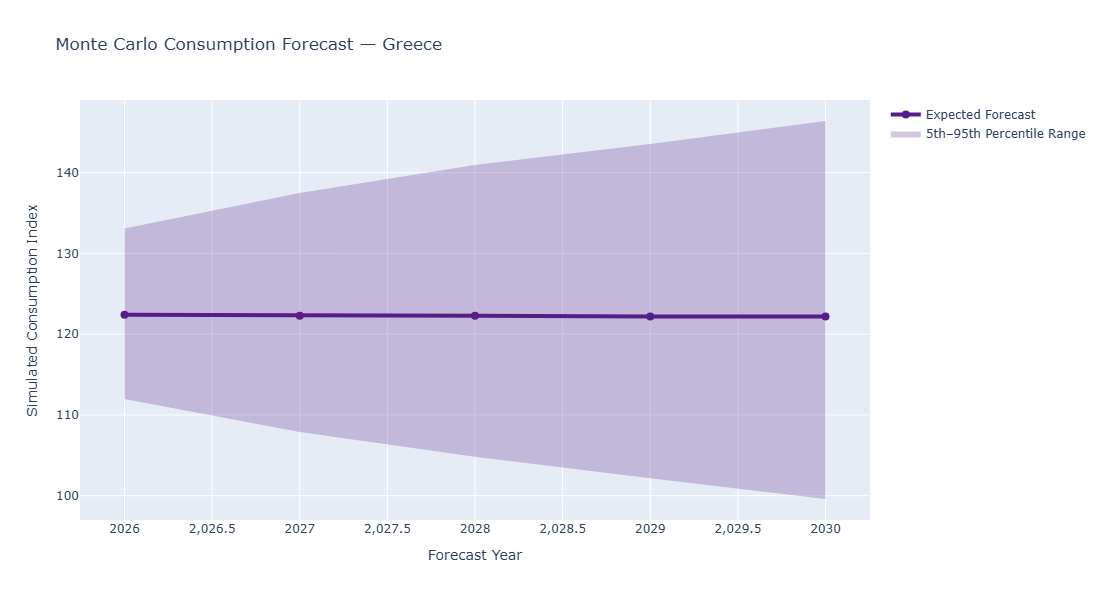

In [50]:
# MONTE CARLO CONFIDENCE BAND

country_to_plot = "Greece"

country_mc = (
    monte_carlo[
        monte_carlo["country"] == country_to_plot
    ]
    .sort_values("forecast_year")
)

fig = go.Figure()

# Upper bound
fig.add_trace(
    go.Scatter(
        x=country_mc["forecast_year"],
        y=country_mc["upside_95th_percentile"],
        mode="lines",
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Lower bound with fill
fig.add_trace(
    go.Scatter(
        x=country_mc["forecast_year"],
        y=country_mc["downside_5th_percentile"],
        mode="lines",
        fill="tonexty",
        fillcolor="rgba(88, 28, 135, 0.25)",
        line=dict(width=0),
        name="5th–95th Percentile Range"
    )
)

# Expected forecast
fig.add_trace(
    go.Scatter(
        x=country_mc["forecast_year"],
        y=country_mc["expected_value"],
        mode="lines+markers",
        line=dict(
            color="#581C87",
            width=4
        ),
        marker=dict(size=8),
        name="Expected Forecast"
    )
)

fig.update_layout(
    title=f"Monte Carlo Consumption Forecast — {country_to_plot}",
    xaxis_title="Forecast Year",
    yaxis_title="Simulated Consumption Index",
    height=600
)

fig.show()

# 10. Crisis Probability Analysis

The simulation also estimates downside economic stress scenarios. Crisis probability measures the share of simulated outcomes that fall below the predefined consumption stress threshold. Higher probabilities indicate greater long-run consumer vulnerability and macroeconomic uncertainty.

In [52]:
# HIGHEST CRISIS PROBABILITY

latest_forecast = (
    monte_carlo[
        monte_carlo["forecast_year"]
        == monte_carlo["forecast_year"].max()
    ]
    .sort_values(
        "crisis_probability",
        ascending=False
    )
)

latest_forecast[
    [
        "country",
        "forecast_year",
        "crisis_probability",
        "forecast_range"
    ]
].head(10)

,country,forecast_year,crisis_probability,forecast_range
59,Greece,2030,0.0211,46.795702
74,Italy,2030,0.0037,35.478690
44,Finland,2030,0.0017,14.722370
39,Estonia,2030,0.0017,33.886330
4,Austria,2030,0.0016,25.764568
129,Spain,2030,0.0002,42.454325
24,Cyprus,2030,0.0001,60.032167
49,France,2030,0.0001,25.223752
54,Germany,2030,0.0001,17.909405
109,Portugal,2030,0.0001,36.782052


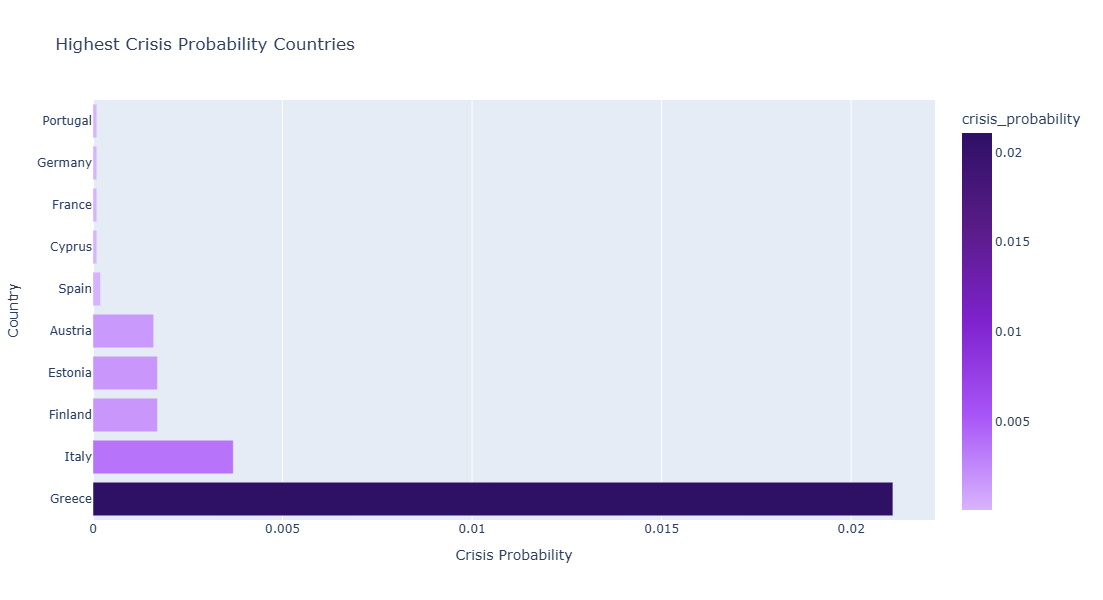

In [54]:
fig = px.bar(
    latest_forecast.head(10),
    x="crisis_probability",
    y="country",
    orientation="h",
    color="crisis_probability",
    color_continuous_scale=[
        "#D8B4FE",
        "#A855F7",
        "#7E22CE",
        "#581C87",
        "#2E1065"
    ],
    title="Highest Crisis Probability Countries"
)

fig.update_layout(
    height=600,
    xaxis_title="Crisis Probability",
    yaxis_title="Country"
)

fig.show()

# 11. Key Findings

### 1. Greece and Southern Europe Show Elevated Long-Term Risk
The model consistently identifies Greece and several Southern European economies as structurally higher-risk environments due to elevated unemployment and weaker consumption stability.

### 2. Inflation Shock Increased Risk Across Europe
The 2022 inflation spike caused a visible increase in macroeconomic consumer stress across most countries.

### 3. Unemployment Is the Strongest Risk Driver
The weighted scoring model shows that unemployment contributes more strongly to long-run consumer economic risk than inflation or consumption fluctuations.

### 4. Forecast Uncertainty Widens Over Time
Monte Carlo simulation results demonstrate that uncertainty increases substantially across longer forecasting horizons.

### 5. Crisis Probabilities Remain Concentrated
Only a limited number of countries exhibit meaningful downside crisis probabilities under simulated stress scenarios.

# 12. Potential Business Applications

This type of macroeconomic consumer risk framework could support:

- regional lending risk assessment,
- consumer credit monitoring,
- stress testing scenarios,
- macroeconomic portfolio analysis,
- and strategic expansion decisions.

## Example Use Cases

### Banking & Consumer Lending
Identify countries with elevated long-run consumer vulnerability before expanding credit exposure.

### Fintech & Buy-Now-Pay-Later Providers
Adjust risk models and approval thresholds based on macroeconomic conditions.

### Investment & Economic Research
Monitor consumer stability and long-run economic resilience across European markets.

### Government & Policy Analysis
Track macroeconomic stress trends and evaluate consumer recovery patterns.

# 13. Project Limitations

While the model provides useful macroeconomic insights, several limitations remain:

- the analysis uses country-level aggregate data rather than household-level microdata,
- risk scoring weights are assumption-based,
- Monte Carlo simulation assumes normally distributed shocks,
- and the model does not incorporate geopolitical or fiscal policy events.

Future improvements could include:
- machine learning forecasting,
- dynamic weighting systems,
- recession regime modeling,
- and household-level consumer credit datasets.